In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
llm = ChatOpenAI()

In [2]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explaination: str

In [ ]:
def generate_joke(state: JokeState):

    prompt = f"""Generate a joke about {state['topic']} and explain it in detail."""
    response = llm.invoke(prompt)

    return {'joke': response}

In [5]:
def generate_explaination(state: JokeState):

    prompt = f"Explain the joke: {state['joke']}"
    response = llm.invoke(prompt)

    return {'explaination': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explaination', generate_explaination)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explaination')
graph.add_edge('generate_explaination', END)

checkpointer = InMemorySaver()


workflow = graph.compile(checkpointer=checkpointer)

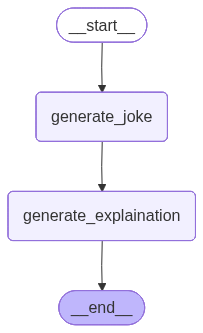

In [7]:
workflow

In [12]:
config_1 = {'configurable': {'thread_id': '1'}}
final_joke = workflow.invoke({'topic': 'pizza'}, config=config_1)
print(final_joke)

{'topic': 'pizza', 'joke': AIMessage(content='Why did the slice of pizza go to the party alone?\n\nBecause it didn\'t want to be topped with anyone else!\n\nThis joke plays on the idea of "toppings" on a pizza and how they can be a personal choice for each individual slice. By saying the slice didn\'t want to be topped with anyone else, it\'s a play on words to suggest that the slice wanted to be left alone, or "topped" with nobody else at the party. It\'s a lighthearted and playful way to incorporate pizza terminology into a joke.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 18, 'total_tokens': 132, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DSg5qJ

In [13]:
workflow.get_state(config_1)

StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why did the slice of pizza go to the party alone?\n\nBecause it didn\'t want to be topped with anyone else!\n\nThis joke plays on the idea of "toppings" on a pizza and how they can be a personal choice for each individual slice. By saying the slice didn\'t want to be topped with anyone else, it\'s a play on words to suggest that the slice wanted to be left alone, or "topped" with nobody else at the party. It\'s a lighthearted and playful way to incorporate pizza terminology into a joke.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 18, 'total_tokens': 132, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, '

In [17]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why did the slice of pizza go to the party alone?\n\nBecause it didn\'t want to be topped with anyone else!\n\nThis joke plays on the idea of "toppings" on a pizza and how they can be a personal choice for each individual slice. By saying the slice didn\'t want to be topped with anyone else, it\'s a play on words to suggest that the slice wanted to be left alone, or "topped" with nobody else at the party. It\'s a lighthearted and playful way to incorporate pizza terminology into a joke.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 18, 'total_tokens': 132, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 

In [ ]:
workflow.get_state_history(config_1)

TypeError: Pregel.get_state_history() got an unexpected keyword argument 'checkpoint_id'